# **Finding How The Data Is Distributed**


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
print('Dataset shape:', df.shape)
print('\nColumn information:')
df.info()

Dataset shape: (65437, 114)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
missing_data = df.isnull().sum()
print('Missing values per column:\n', missing_data[missing_data > 0].sort_values(ascending=False))

Missing values per column:
 AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
YearsCode                      5568
NEWSOSites                     5151
LearnCode                      4949
EdLevel                        4653
AISelect                       4530
Length: 109, dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
print('Value counts for Employment:\n', df['Employment'].value_counts())
print('\nValue counts for JobSat:\n', df['JobSat'].value_counts())
print('\nValue counts for YearsCodePro:\n', df['YearsCodePro'].value_counts())

Value counts for Employment:
 Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looki

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


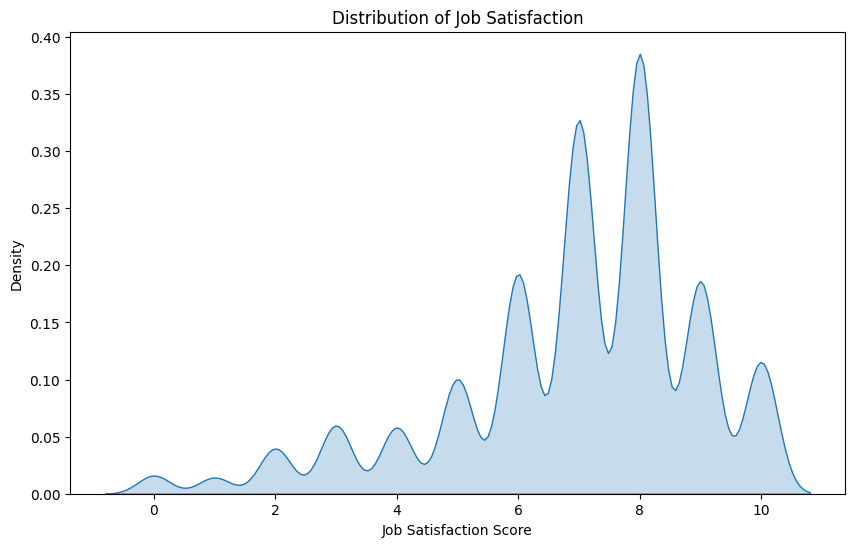


Interpretation: The KDE plot shows the density distribution of Job Satisfaction scores.

The mean job satisfaction score is approximately 6.94 and the median is 7.0.

The plot reveals the peaks in satisfaction levels, indicating common ranges of job satisfaction among respondents.
We can observe if the distribution is skewed towards higher or lower satisfaction, or if there are multiple peaks.


In [6]:
# Visualize the distribution of JobSat using a KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df['JobSat'].dropna(), fill=True)
plt.title('Distribution of Job Satisfaction')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Density')
plt.show()

# Interpretation of the plot
job_sat_mean = df['JobSat'].mean()
job_sat_median = df['JobSat'].median()
print(f"\nInterpretation: The KDE plot shows the density distribution of Job Satisfaction scores.\n")
print(f"The mean job satisfaction score is approximately {job_sat_mean:.2f} and the median is {job_sat_median}.\n")
print(f"The plot reveals the peaks in satisfaction levels, indicating common ranges of job satisfaction among respondents.")
print(f"We can observe if the distribution is skewed towards higher or lower satisfaction, or if there are multiple peaks.")

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


/tmp/ipykernel_448/403453879.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_worked_with.values, y=top_worked_with.index, palette='viridis')
/tmp/ipykernel_448/403453879.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_want_to_work_with.values, y=top_want_to_work_with.index, palette='magma')


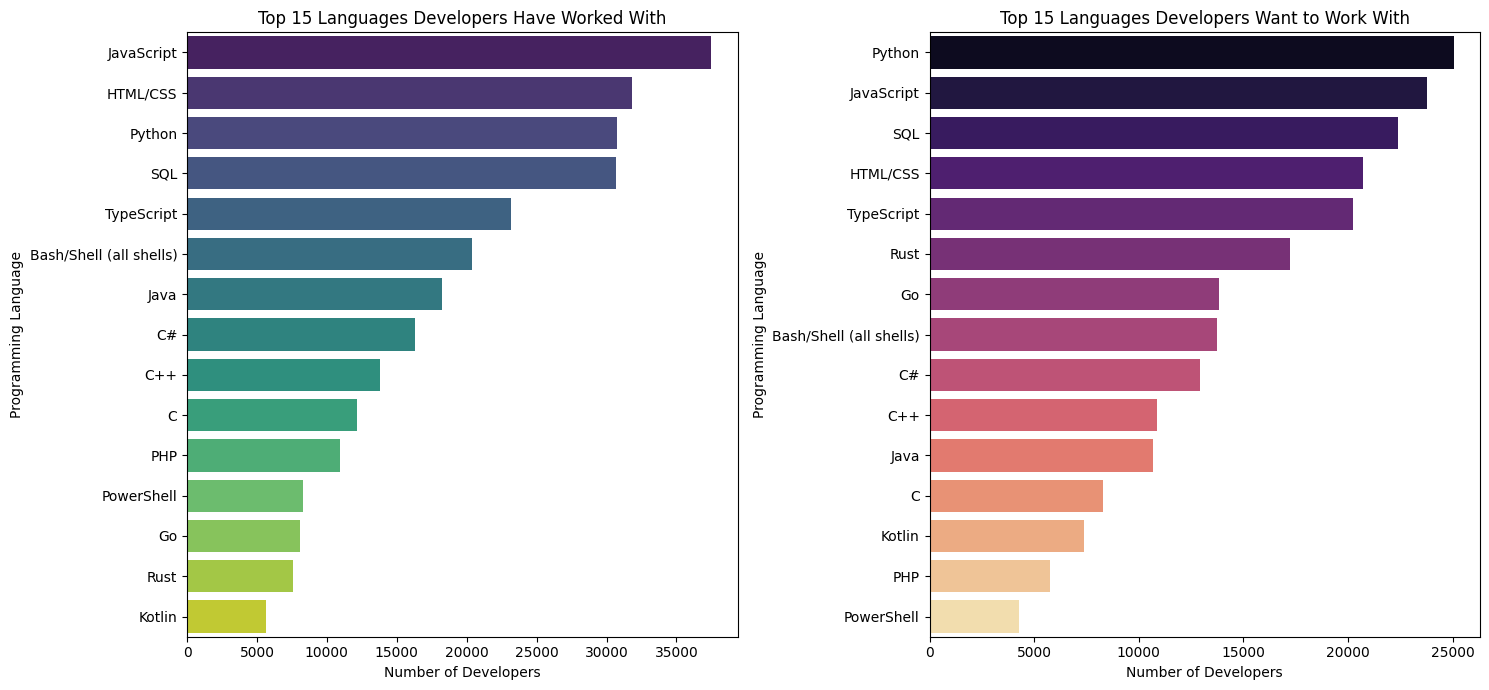

Interpretation: The plots compare the popularity of programming languages. 'Top Languages Developers Have Worked With' shows the current landscape, while 'Top Languages Developers Want to Work With' indicates emerging trends and future interests. Significant overlap suggests stability, while differences highlight potential shifts in the industry.


In [7]:
# Function to split and count languages
def count_languages(df, column_name):
    languages = df[column_name].dropna().apply(lambda x: x.split(';'))
    all_languages = [lang.strip() for sublist in languages for lang in sublist]
    return pd.Series(all_languages).value_counts()

# Count languages developers have worked with
worked_with_languages = count_languages(df, 'LanguageHaveWorkedWith')

# Count languages developers want to work with
want_to_work_with_languages = count_languages(df, 'LanguageWantToWorkWith')

# Get the top N languages for visualization
top_n = 15
top_worked_with = worked_with_languages.head(top_n)
top_want_to_work_with = want_to_work_with_languages.head(top_n)

# Create a figure with two subplots
plt.figure(figsize=(15, 7))

# Plot for languages developers have worked with
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x=top_worked_with.values, y=top_worked_with.index, palette='viridis')
plt.title(f'Top {top_n} Languages Developers Have Worked With')
plt.xlabel('Number of Developers')
plt.ylabel('Programming Language')

# Plot for languages developers want to work with
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x=top_want_to_work_with.values, y=top_want_to_work_with.index, palette='magma')
plt.title(f'Top {top_n} Languages Developers Want to Work With')
plt.xlabel('Number of Developers')
plt.ylabel('Programming Language')

plt.tight_layout()
plt.show()

print("Interpretation: The plots compare the popularity of programming languages. 'Top Languages Developers Have Worked With' shows the current landscape, while 'Top Languages Developers Want to Work With' indicates emerging trends and future interests. Significant overlap suggests stability, while differences highlight potential shifts in the industry.")

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


<Figure size 1800x900 with 0 Axes>

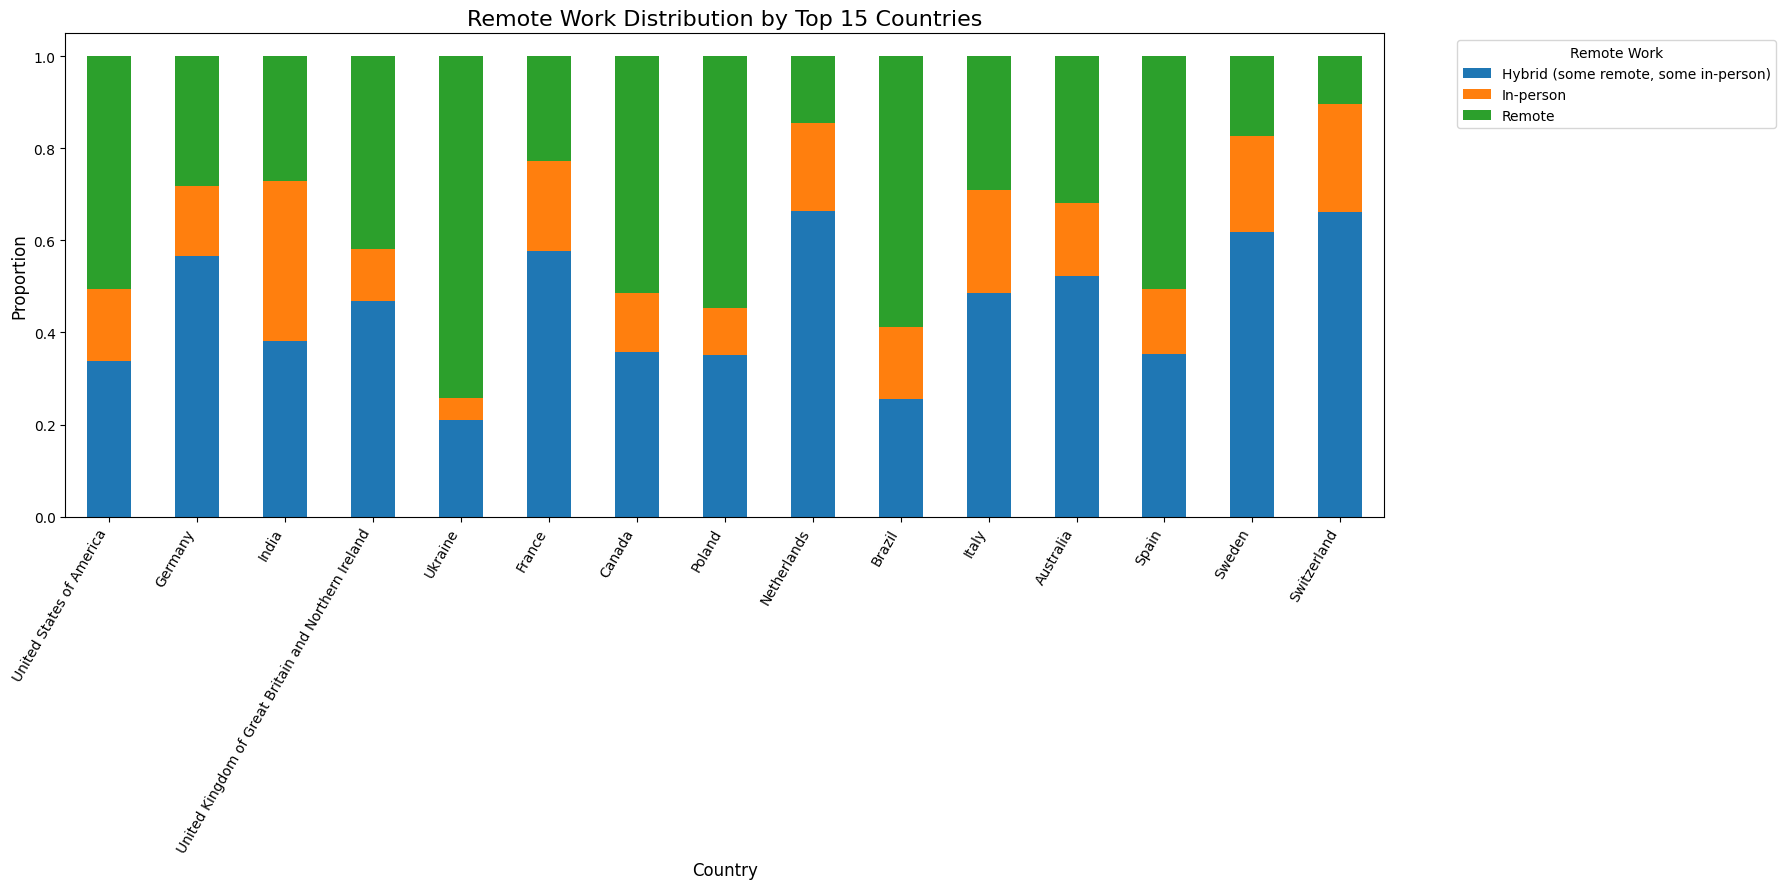


Interpretation: This stacked bar chart displays the proportion of different remote work arrangements (e.g., Remote, Hybrid, In-person) for the top countries. It helps us visualize and compare regional differences in remote work trends and preferences among developers.


In [8]:
# To analyze RemoteWork trends, we need a 'Country' column to represent 'region'.
# Let's check if the 'Country' column exists and proceed.

if 'Country' in df.columns:
    # Handle missing values in RemoteWork and Country for analysis
    df_remote_country = df.dropna(subset=['RemoteWork', 'Country']).copy()

    # Cross-tabulate RemoteWork and Country
    # We'll normalize by index to get proportions within each country
    remote_work_country_counts = df_remote_country.groupby(['Country', 'RemoteWork']).size().unstack(fill_value=0)
    remote_work_country_proportion = remote_work_country_counts.div(remote_work_country_counts.sum(axis=1), axis=0)

    # Select top N countries for visualization to avoid clutter
    top_n_countries = 15 # You can adjust this number
    top_countries = df_remote_country['Country'].value_counts().nlargest(top_n_countries).index
    remote_work_country_top = remote_work_country_proportion.loc[top_countries]

    # Plotting
    plt.figure(figsize=(18, 9))
    remote_work_country_top.plot(kind='bar', stacked=True, figsize=(18, 9))
    plt.title(f'Remote Work Distribution by Top {top_n_countries} Countries', fontsize=16)
    plt.xlabel('Country', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.xticks(rotation=60, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Remote Work', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

    print("\nInterpretation: This stacked bar chart displays the proportion of different remote work arrangements (e.g., Remote, Hybrid, In-person) for the top countries. It helps us visualize and compare regional differences in remote work trends and preferences among developers.")
else:
    print("The 'Country' column was not found in the dataset. Cannot analyze remote work trends by region as instructed.")
    print("Available columns: ", df.columns.tolist())



### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [9]:
# Convert 'YearsCodePro' to a numerical format
# Replace 'Less than 1 year' with 0 and 'More than 50 years' with 51 (or a suitable large number)
# Then convert the column to numeric, coercing errors to NaN
df_filtered = df.copy()
df_filtered['YearsCodePro_numeric'] = df_filtered['YearsCodePro'].replace({'Less than 1 year': '0', 'More than 50 years': '51'}).astype(float)

# Calculate Pearson correlation between JobSat and YearsCodePro_numeric
correlation = df_filtered['JobSat'].corr(df_filtered['YearsCodePro_numeric'], method='pearson')

print(f"Pearson Correlation between Job Satisfaction and Professional Coding Experience: {correlation:.2f}")

print("\nInterpretation: This correlation coefficient indicates the strength and direction of a linear relationship between job satisfaction and years of professional coding experience.")
print("A positive value suggests that as professional coding experience increases, job satisfaction tends to increase, while a negative value would suggest the opposite.")
print("A value close to zero indicates a weak or no linear relationship.")

Pearson Correlation between Job Satisfaction and Professional Coding Experience: 0.10

Interpretation: This correlation coefficient indicates the strength and direction of a linear relationship between job satisfaction and years of professional coding experience.
A positive value suggests that as professional coding experience increases, job satisfaction tends to increase, while a negative value would suggest the opposite.
A value close to zero indicates a weak or no linear relationship.


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Cross-tabulation of Education Level and Employment Status:
 Employment                                          Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                1059   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      16806   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                   11011   
Primary/elementary school                                           160   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     2073   
Secondary school (e.g. American high school, Ge...                 1460   
Some college/university study without earning a...                 3579   
Something else                                                      377   

Employment                                          Employed, full-time;Employed, part-time  \
EdLevel                                                                                       

/tmp/ipykernel_448/1054844773.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1500x800 with 0 Axes>

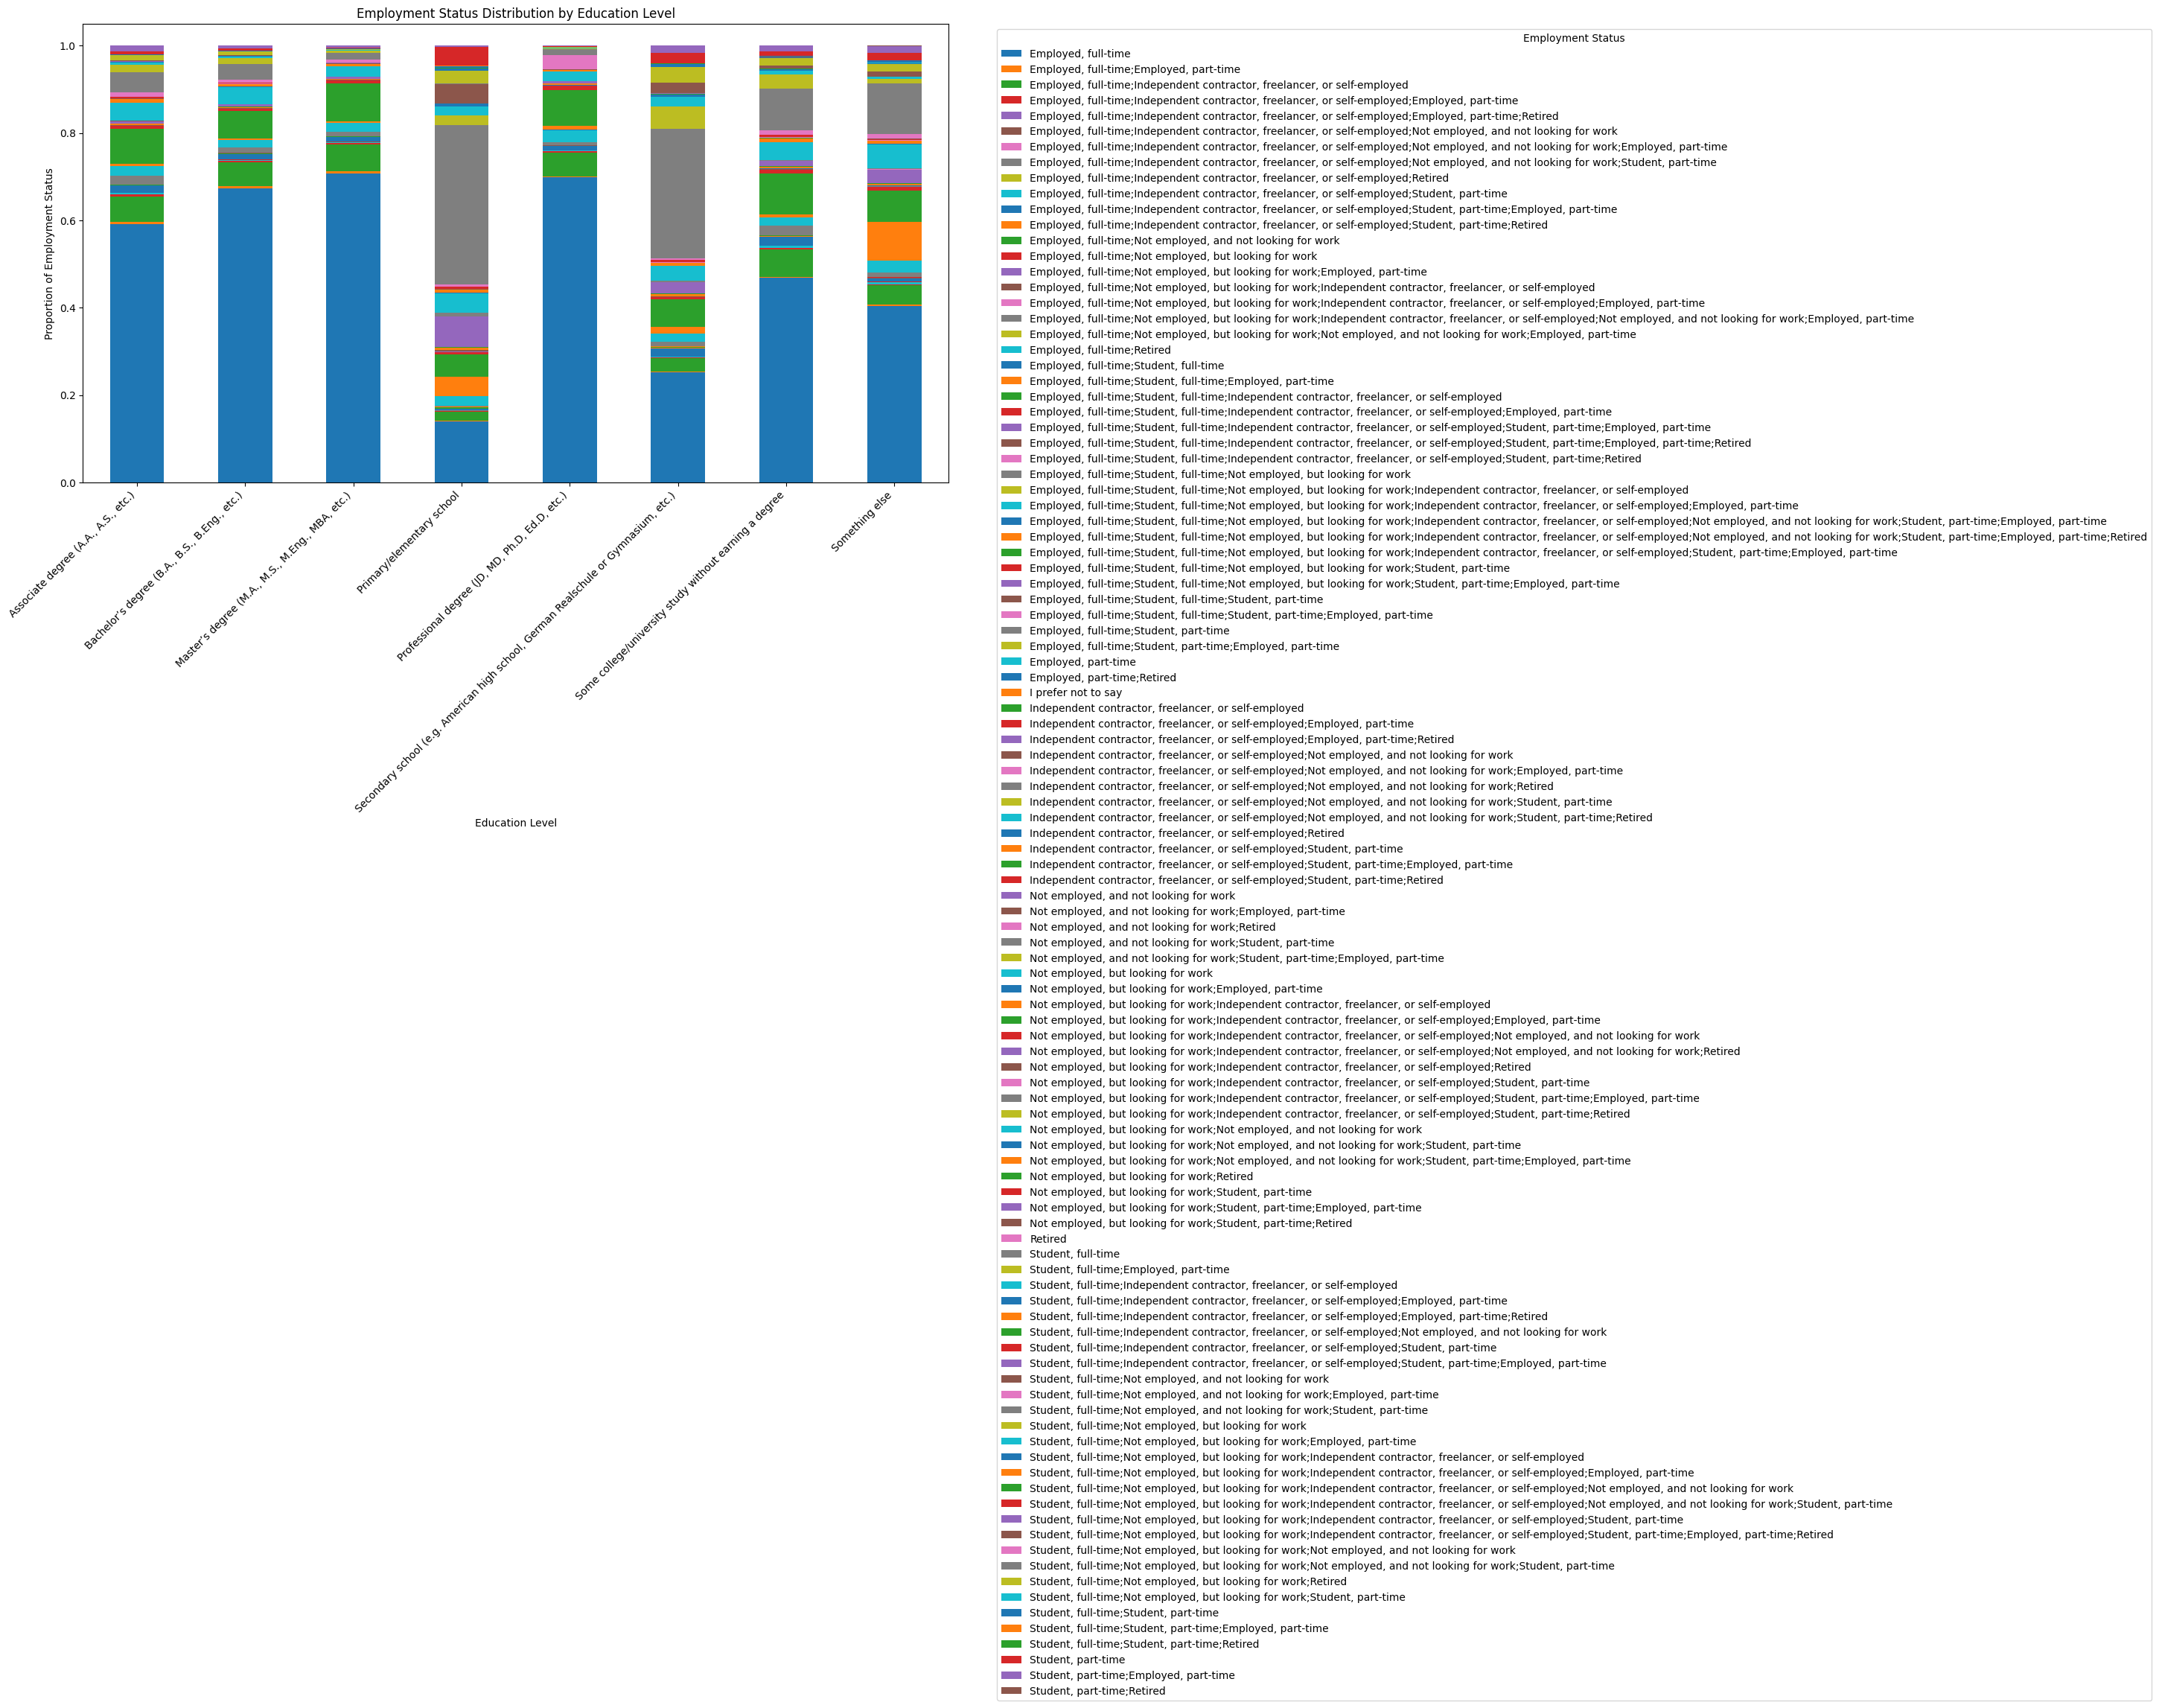


Interpretation: This stacked bar chart visualizes how different employment statuses are distributed across various education levels. It helps identify common career paths or employment challenges associated with specific educational backgrounds.


In [10]:
# Create a cross-tabulation of Employment and EdLevel
crosstab_education_employment = pd.crosstab(df['EdLevel'], df['Employment'])

# Display the cross-tabulation
print('Cross-tabulation of Education Level and Employment Status:\n', crosstab_education_employment)

# Visualize the cross-tabulation using a stacked bar plot
# Normalize by index to show proportions within each education level
crosstab_norm = crosstab_education_employment.div(crosstab_education_employment.sum(1).astype(float), axis=0)

plt.figure(figsize=(15, 8))
crosstab_norm.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Employment Status Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Proportion of Employment Status')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nInterpretation: This stacked bar chart visualizes how different employment statuses are distributed across various education levels. It helps identify common career paths or employment challenges associated with specific educational backgrounds.")

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [11]:
# Save the cleaned dataset to a new CSV file
df_filtered.to_csv('cleaned_survey_data.csv', index=False)
print("Cleaned dataset saved to 'cleaned_survey_data.csv'")

Cleaned dataset saved to 'cleaned_survey_data.csv'


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
